https://github.com/bulletphysics/bullet3/blob/master/docs/pybullet_quickstart_guide/PyBulletQuickstartGuide.md.html 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data = np.load(open("cuboid_simulations/2023_01_18_16_27_32_118205.npy", "rb"))

In [5]:
data.shape
# (num_timesteps, num_objects, values)
# where values are (x, y, z, q1, q2, q3, q4) and q are the quaternion rotation parameters

(500, 10, 11)

In [6]:
# Normalized Euclidean distance between subsequent timesteps of an object's position
# though for performance reasons we simply do all objects at the same time in a vectorized manner
# (normalized over all the objects' trajectories, but always just within one simulation; which can be problematic,
# e.g. if none of the objects move; so perhaps do some clipping)
# think of it as "how much the position of each item is changing"
dist = np.sqrt( np.square(data[1:,:,0]-data[:-1,:,0])
               +np.square(data[1:,:,1]-data[:-1,:,1])
               +np.square(data[1:,:,2]-data[:-1,:,2]))
# dist

In [7]:
norm_dist = (dist-dist.min())/(dist.max()-dist.min())
# norm_dist

# Just for simplicity, let's quickly min-clip values to 0.01
# clip_dist = np.clip(norm_dist, 1e-2, None)
# clip_dist

In [8]:
# Determine the timestep of last change from norm_dist
# FIXME
# has_moved = norm_dist[1:]-norm_dist[:-1]>0.01
# has_moved = np.logical_or(has_moved[:,0], has_moved[:,1])
# no_change_timestep = np.argwhere(has_moved==True)[0, 0]
# no_change_timestep = len(norm_dist)
no_change_timesteps = np.argwhere(norm_dist.sum(axis=1)<0.0001)
if len(no_change_timesteps) > 0:
    no_change_timestep = no_change_timesteps[0,0]
else:
    no_change_timestep = len(norm_dist)

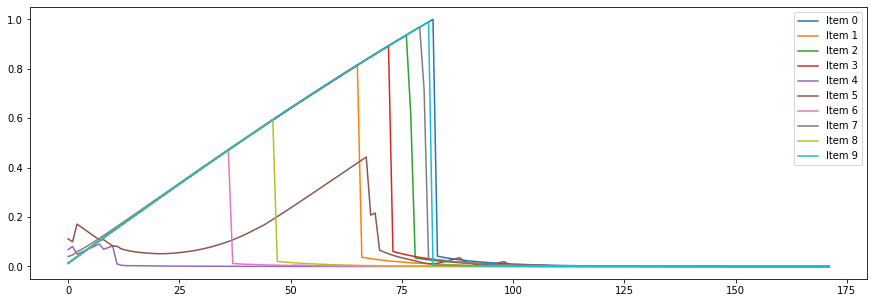

In [9]:
# plt.figure(figsize=(15, 7))
# plt.plot(range(no_change_timestep), data[:no_change_timestep,0,0])
# plt.plot(range(no_change_timestep), data[:no_change_timestep,0,1])
# plt.plot(range(no_change_timestep), data[:no_change_timestep,0,2])

# Plot normalized distances
plt.figure(figsize=(15, 5))
for item in range(data.shape[1]):
    # plt.plot(range(len(norm_dist)), norm_dist[:,item], label=f"Item {item}")
    plt.plot(range(no_change_timestep), norm_dist[:no_change_timestep,item], label=f"Item {item}")
plt.legend();

In [226]:
# TODO: 3d plot of item trajectories

In [10]:
"""
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.imshow(np.load(open(f"screenshots/2023_01_18_00_46_33_073607_t_400_rgb.npy", "rb"), allow_pickle=True))
""";